<a href="https://colab.research.google.com/github/godmsqls/Big-Data-Processing-and-Applications-Practice/blob/main/KW_MMDS_Colab_0_(Spark_Tutorial).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS246 - Colab 0
## Spark Tutorial

In this tutorial you will learn how to use [Apache Spark](https://spark.apache.org) in local mode on a Colab enviroment.

Credits to [Tiziano Piccardi](http://piccardi.me/) for his Spark Tutorial used in the Applied Data Analysis class at EPFL.

원본 링크: https://colab.research.google.com/drive/1gc6u6hItUKY9uJt6GXHaneSYCMaGcxp1?usp=sharing

### Setup

Let's setup Spark on your Colab environment.  Run the cell below! (필수 프로그램 설치)

In [1]:
!pip install pyspark
!pip install -U -q PyDrive2
#the output 'xxx is not a symbolic link' will not affect your implementation or execution
#to fix 'xxx is not a symbolic link', you can uncomment the lines starting from !mv xxxx
#you may need to replace xxx.11 with the correct version if other errors come up after colab update
#to get the correct version, use !ls /usr/local/lib to find out
#!mv /usr/local/lib/libtbbmalloc_proxy.so.2 /usr/local/lib/libtbbmalloc_proxy.so.2.backup
#!mv /usr/local/lib/libtbbmalloc.so.2 /usr/local/lib/libtbbmalloc.so.2.backup
#!mv /usr/local/lib/libtbbbind_2_5.so.3 /usr/local/lib/libtbbbind_2_5.so.3.backup
#!mv /usr/local/lib/libtbb.so.12 /usr/local/lib/libtbb.so.12.backup
#!mv /usr/local/lib/libtbbbind_2_0.so.3 /usr/local/lib/libtbbbind_2_0.so.3.backup
#!mv /usr/local/lib/libtbbbind.so.3 /usr/local/lib/libtbbbind.so.3.backup
#!ln -s /usr/local/lib/libtbbmalloc_proxy.so.2.11 /usr/local/lib/libtbbmalloc_proxy.so.2
#!ln -s /usr/local/lib/libtbbmalloc.so.2.11 /usr/local/lib/libtbbmalloc.so.2
#!ln -s /usr/local/lib/libtbbbind_2_5.so.3.11 /usr/local/lib/libtbbbind_2_5.so.3
#!ln -s /usr/local/lib/libtbb.so.12.11 /usr/local/lib/libtbb.so.12
#!ln -s /usr/local/lib/libtbbbind_2_0.so.3.11 /usr/local/lib/libtbbbind_2_0.so.3
#!ln -s /usr/local/lib/libtbbbind.so.3.11 /usr/local/lib/libtbbbind.so.3
#If error related to the above execution occurs, you can try commenting out the above 12 lines under pip install PyDrive2 (not included)

# !sudo ldconfig
!apt install openjdk-17-jdk-headless -qq
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.0/48.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 3.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
authlib 1.8.0 requires cryptography>=45.0.1, but you have cryptography 43.0.3 which is incompatible.
joserfc 1.7.5 requires cryptography>=45.0.1, but you have cryptography 43.0.3 which is incompatible.
The following additional packages will be installed:
  openjdk-17-jre-headless
Suggested packages:
  openjdk-17-demo openjdk-17-source libnss-mdns fonts-dejavu-extra
  fonts-ipafont-gothic fonts-ipafont-mincho fonts-wqy-microhei
  | fonts-wqy-zenhei fonts-indic
The following NEW packages will be installed:
  openjdk-17-jdk-headless openjdk-17-jre-headless
0 upgraded, 2 newly installed, 0

Now we authenticate a Google Drive client to download the file we will be processing in our Spark job.

**Make sure to follow the interactive instructions.** (구글 드라이브를 통해 필요한 파일 다운로드)

In [2]:
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

# Authenticate and create the PyDrive client
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

In [3]:
id='1L6pCQkldvdBoaEhRFzL0VnrggEFvqON4'
downloaded = drive.CreateFile({'id': id})
downloaded.GetContentFile('Bombing_Operations.json.gz')

id='14dyBmcTBA32uXPxDbqr0bFDIzGxMTWwl'
downloaded = drive.CreateFile({'id': id})
downloaded.GetContentFile('Aircraft_Glossary.json.gz')

If you executed the cells above, you should be able to see the files *Bombing_Operations.json.gz* and *Aircraft_Glossary.json.gz* under the "Files" tab on the left panel. (왼쪽 파일 패널 /content/ 에서 다운로드 받은 파일 확인 가능)

In [4]:
# Let's import the libraries we will need (라이브러리 불러오기)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import pyspark
from pyspark.sql import *
from pyspark.sql.functions import *
from pyspark import SparkContext, SparkConf

Let's initialize the Spark context. (Spark 초기화)


In [5]:
# create the session
conf = SparkConf().set("spark.ui.port", "4050")

# create the context
sc = pyspark.SparkContext(conf=conf)
spark = SparkSession.builder.getOrCreate()

Load the datasets: (입력 파일을 Spark의 DataFrame 형식으로 읽기)

In [6]:
Bombing_Operations = spark.read.json("Bombing_Operations.json.gz")
Aircraft_Glossary = spark.read.json("Aircraft_Glossary.json.gz")

Check the schema: (Spark의 DataFrame에서 지원)

In [ ]:
Bombing_Operations.printSchema()

root
 |-- AirCraft: string (nullable = true)
 |-- ContryFlyingMission: string (nullable = true)
 |-- MissionDate: string (nullable = true)
 |-- OperationSupported: string (nullable = true)
 |-- PeriodOfDay: string (nullable = true)
 |-- TakeoffLocation: string (nullable = true)
 |-- TargetCountry: string (nullable = true)
 |-- TimeOnTarget: double (nullable = true)
 |-- WeaponType: string (nullable = true)
 |-- WeaponsLoadedWeight: long (nullable = true)



In [ ]:
Aircraft_Glossary.printSchema()

root
 |-- AirCraft: string (nullable = true)
 |-- AirCraftName: string (nullable = true)
 |-- AirCraftType: string (nullable = true)



Get a sample with `take()`: (Spark의 DataFrame에서 지원)

In [ ]:
Bombing_Operations.take(10)

[Row(AirCraft='EC-47', ContryFlyingMission='UNITED STATES OF AMERICA', MissionDate='1971-06-05', OperationSupported=None, PeriodOfDay='D', TakeoffLocation='TAN SON NHUT', TargetCountry='CAMBODIA', TimeOnTarget=1005.0, WeaponType=None, WeaponsLoadedWeight=0),
 Row(AirCraft='EC-47', ContryFlyingMission='UNITED STATES OF AMERICA', MissionDate='1972-12-26', OperationSupported=None, PeriodOfDay='D', TakeoffLocation='NAKHON PHANOM', TargetCountry='SOUTH VIETNAM', TimeOnTarget=530.0, WeaponType=None, WeaponsLoadedWeight=0),
 Row(AirCraft='RF-4', ContryFlyingMission='UNITED STATES OF AMERICA', MissionDate='1973-07-28', OperationSupported=None, PeriodOfDay='D', TakeoffLocation='UDORN AB', TargetCountry='LAOS', TimeOnTarget=730.0, WeaponType=None, WeaponsLoadedWeight=0),
 Row(AirCraft='A-1', ContryFlyingMission='UNITED STATES OF AMERICA', MissionDate='1970-02-02', OperationSupported=None, PeriodOfDay='N', TakeoffLocation='NAKHON PHANOM', TargetCountry='LAOS', TimeOnTarget=1415.0, WeaponType='BLU

Get a formatted sample with `show()`: (Spark의 DataFrame에서 지원)

In [ ]:
Aircraft_Glossary.show()

+--------+--------------------+--------------------+
|AirCraft|        AirCraftName|        AirCraftType|
+--------+--------------------+--------------------+
|     A-1|Douglas A-1 Skyra...|         Fighter Jet|
|    A-26|Douglas A-26 Invader|        Light Bomber|
|    A-37|Cessna A-37 Drago...|Light ground-atta...|
|     A-4|McDonnell Douglas...|         Fighter Jet|
|     A-5|North American A-...|          Bomber Jet|
|     A-6|Grumman A-6 Intruder|     Attack Aircraft|
|     A-7|  LTV A-7 Corsair II|     Attack Aircraft|
|  AC-119|Fairchild AC-119 ...|Military Transpor...|
|  AC-123|Fairchild C-123 P...|Military Transpor...|
|  AC-130|Lockheed AC-130 S...|Fixed wing ground...|
|   AC-47|Douglas AC-47 Spooky|Ground attack air...|
|    AH-1| Bell AH-1 HueyCobra|          Helicopter|
|     B-1| Rockwell B-1 Lancer|Heavy strategic b...|
|    B-52| B-52 Stratofortress|    Strategic bomber|
|    B-57|Martin B-57 Canberra|     Tactical Bomber|
|    B-66|Douglas B-66 Dest...|        Light B

In [ ]:
print("In total there are {0} operations".format(Bombing_Operations.count()))

In total there are 4400775 operations


In [ ]:
# format 예제
my_string = "{0}, {1}!".format("Hello", "World")
print(my_string)
my_string = "{0}".format(1+2)
print(my_string)

Hello, World!
3


### ------------- **Spark tutorial(2)** ------------------
## Question 1: Which countries are involved and in how many missions?
## 각 국가가 참가한 전체 임무의 수를 구하라.

Keywords: `Dataframe API`, `SQL`, `group by`, `sort`

Let's group the missions by `ContryFlyingMission` and count how many records exist:

In [ ]:
# 국가별로 모은 데이터
grouped = Bombing_Operations.groupBy("ContryFlyingMission")

In [ ]:
# 데이터의 개수 세기
counts = grouped.count()
counts.show()

+--------------------+-------+
| ContryFlyingMission|  count|
+--------------------+-------+
|     VIETNAM (SOUTH)| 622013|
|       KOREA (SOUTH)|  24469|
|UNITED STATES OF ...|3708997|
|           AUSTRALIA|  12519|
|                LAOS|  32777|
+--------------------+-------+



In [ ]:
# 정렬하기
counts = counts.sort("count")

# truncate=False 속성을 통해 나라 이름 끝까지 출력
counts.show(truncate=False)

+------------------------+-------+
|ContryFlyingMission     |count  |
+------------------------+-------+
|AUSTRALIA               |12519  |
|KOREA (SOUTH)           |24469  |
|LAOS                    |32777  |
|VIETNAM (SOUTH)         |622013 |
|UNITED STATES OF AMERICA|3708997|
+------------------------+-------+



The Dataframe is small enough to be moved to Pandas:
(Spark DataFrame에서 Pandas DataFrame으로 변환하기)

In [ ]:
missions_count_pd = counts.toPandas()
missions_count_pd.head()

,ContryFlyingMission,count
0,AUSTRALIA,12519
1,KOREA (SOUTH),24469
2,LAOS,32777
3,VIETNAM (SOUTH),622013
4,UNITED STATES OF AMERICA,3708997


Let's plot a barchart with the number of missions by country: (Pandas DataFrame으로 차트 그리기)

Text(0.5, 1.0, 'Number of missions by Country')

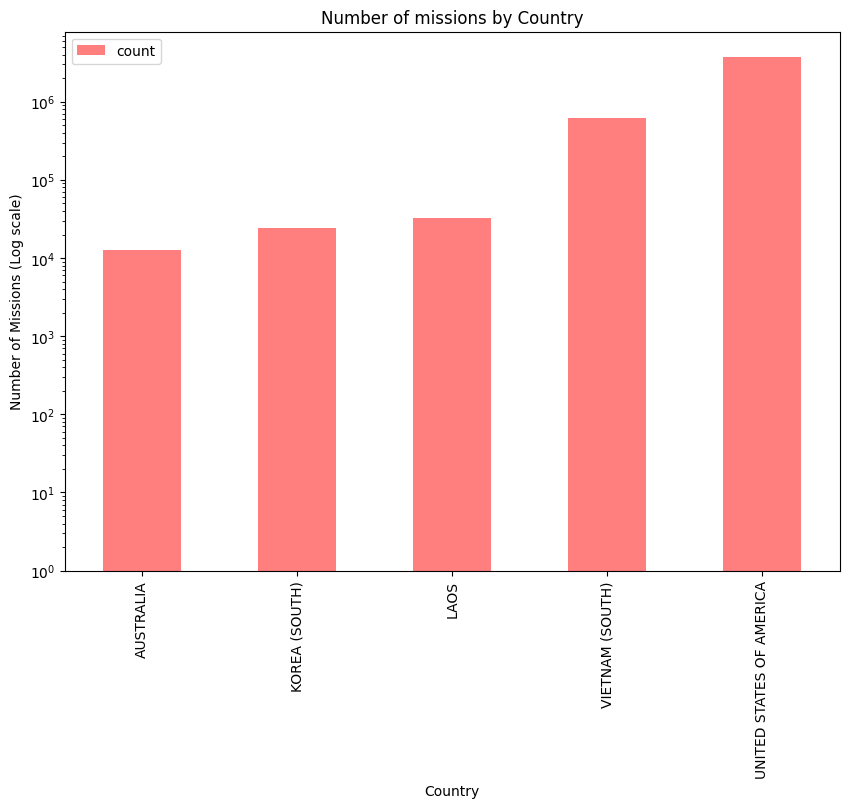

In [ ]:
pl = missions_count_pd.plot(kind="bar",
                            x="ContryFlyingMission", y="count",
                            figsize=(10, 7), log=True, alpha=0.5, color="red")
pl.set_xlabel("Country")
pl.set_ylabel("Number of Missions (Log scale)")
pl.set_title("Number of missions by Country")

SQL은 데이터베이스 시간에 ...

In this case we used the DataFrame API, but we could rewite the `groupBy` using pure SQL:

In [ ]:
Bombing_Operations.createOrReplaceTempView("Bombing_Operations")

query = """
SELECT ContryFlyingMission, count(*) as MissionsCount
FROM Bombing_Operations
GROUP BY ContryFlyingMission
ORDER BY MissionsCount DESC
"""

missions_counts = spark.sql(query)
missions_counts.show()

+--------------------+-------------+
| ContryFlyingMission|MissionsCount|
+--------------------+-------------+
|UNITED STATES OF ...|      3708997|
|     VIETNAM (SOUTH)|       622013|
|                LAOS|        32777|
|       KOREA (SOUTH)|        24469|
|           AUSTRALIA|        12519|
+--------------------+-------------+



----

## Questions 2: Show the number of missions in time for each of the countries involved.
## 매일 얼마나 많은 임무에 참가했는지 나라별로 구하시오.

Keywords: `group by`, `parse date`, `plot`

Let's select the relevant columns:

In [ ]:
# 그림 그리기 실패하는 코드
#grouped = Bombing_Operations.groupBy(["MissionDate", "ContryFlyingMission"])
#counts = grouped.count()
#counts = counts.sort("MissionDate")
#counts.show()

In [ ]:
# 문자열을 date로 변환하면서 일자와 국가 두 개의 열만 가져오는 코드
# to_date를 함으로써 문자열 -> 날짜로 인식 가능, 그림 그리기 성공
missions_countries = Bombing_Operations.selectExpr(["to_date(MissionDate) as MissionDate", "ContryFlyingMission"])
missions_countries.printSchema()

root
 |-- MissionDate: date (nullable = true)
 |-- ContryFlyingMission: string (nullable = true)



The filed MissionDate is converted to a Python `date` object.

Now we can group by `MissionDate` and `ContryFlyingMission` to get the count:

In [ ]:
# 일자와 국가가 같은 데이터 모으기
grouped = missions_countries.groupBy(["MissionDate", "ContryFlyingMission"])

In [ ]:
# 데이터의 개수 세기
counts = grouped.count()
counts.show()

+-----------+--------------------+-----+
|MissionDate| ContryFlyingMission|count|
+-----------+--------------------+-----+
| 1971-10-05|UNITED STATES OF ...|  650|
| 1972-10-26|UNITED STATES OF ...|  921|
| 1972-03-04|UNITED STATES OF ...| 1084|
| 1973-11-03|     VIETNAM (SOUTH)|  192|
| 1970-03-27|UNITED STATES OF ...| 2466|
| 1970-12-28|     VIETNAM (SOUTH)|  291|
| 1971-10-14|     VIETNAM (SOUTH)|  386|
| 1973-10-05|UNITED STATES OF ...|  105|
| 1973-12-05|     VIETNAM (SOUTH)|  197|
| 1971-07-15|     VIETNAM (SOUTH)|  336|
| 1973-10-29|     VIETNAM (SOUTH)|  207|
| 1972-05-01|UNITED STATES OF ...| 1537|
| 1974-02-13|     VIETNAM (SOUTH)|  250|
| 1971-09-25|     VIETNAM (SOUTH)|  354|
| 1972-03-07|UNITED STATES OF ...| 1034|
| 1974-03-26|UNITED STATES OF ...|   79|
| 1971-07-31|     VIETNAM (SOUTH)|  347|
| 1970-08-10|UNITED STATES OF ...| 1268|
| 1970-03-06|     VIETNAM (SOUTH)|  259|
| 1970-11-03|           AUSTRALIA|   21|
+-----------+--------------------+-----+
only showing top

In [ ]:
# 정렬하기
counts = counts.sort("MissionDate")
counts.show()

+-----------+--------------------+-----+
|MissionDate| ContryFlyingMission|count|
+-----------+--------------------+-----+
| 1965-10-01|UNITED STATES OF ...|  447|
| 1965-10-02|UNITED STATES OF ...|  652|
| 1965-10-03|UNITED STATES OF ...|  608|
| 1965-10-04|UNITED STATES OF ...|  532|
| 1965-10-05|UNITED STATES OF ...|  697|
| 1965-10-05|     VIETNAM (SOUTH)|   72|
| 1965-10-06|     VIETNAM (SOUTH)|   49|
| 1965-10-06|UNITED STATES OF ...|  689|
| 1965-10-07|UNITED STATES OF ...|  605|
| 1965-10-07|     VIETNAM (SOUTH)|   50|
| 1965-10-08|UNITED STATES OF ...|  700|
| 1965-10-08|     VIETNAM (SOUTH)|   64|
| 1965-10-09|     VIETNAM (SOUTH)|   69|
| 1965-10-09|UNITED STATES OF ...|  677|
| 1965-10-10|     VIETNAM (SOUTH)|   59|
| 1965-10-10|UNITED STATES OF ...|  789|
| 1965-10-11|     VIETNAM (SOUTH)|   48|
| 1965-10-11|UNITED STATES OF ...|  455|
| 1965-10-12|UNITED STATES OF ...|  449|
| 1965-10-12|     VIETNAM (SOUTH)|   62|
+-----------+--------------------+-----+
only showing top

Now we can plot the content with a different series for each country:

In [ ]:
# Pandas로 변환
counts_pd = counts.toPandas()

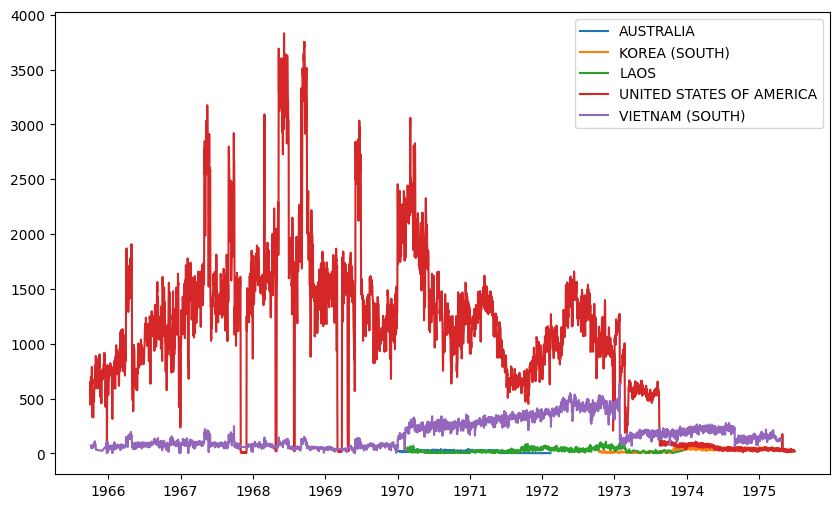

In [ ]:
fig = plt.figure(figsize=(10, 6))

# iterate the different groups to create a different series
for country, missions in counts_pd.groupby("ContryFlyingMission"):
    plt.plot(missions["MissionDate"], missions["count"], label=country)

plt.legend(loc='best')

We can observe how South Vietnam increased its missions starting from 1970. The drop in 1973 is motivated by the [Paris Peace Accords](https://en.wikipedia.org/wiki/Paris_Peace_Accords) that took place on January 27th, 1973, to establish peace in Vietnam and end the war.

----

## ------------------------ **Spark tutorial(3)** ------------------
## Question 3: Who bombed this location?


Keywords: `RDD map reduce` `cache` `save results`

<img style="float: right;" src="https://raw.githubusercontent.com/epfl-ada/2019/c17af0d3c73f11cb083717b7408fedd86245dc4d/Tutorials/04%20-%20Scaling%20Up/img/Hanoi_POL1966.jpg">

This picture is the Hanoi POL facility (North Vietnam) burning after it was attacked by the U.S. Air Force on 29 June 1966 in the context of the Rolling Thunder operation.

We are interested in discovering what was the most common take-off location during that day.

In [7]:
Bombing_Operations.show()

+--------+--------------------+-----------+------------------+-----------+---------------+-------------+------------+--------------------+-------------------+
|AirCraft| ContryFlyingMission|MissionDate|OperationSupported|PeriodOfDay|TakeoffLocation|TargetCountry|TimeOnTarget|          WeaponType|WeaponsLoadedWeight|
+--------+--------------------+-----------+------------------+-----------+---------------+-------------+------------+--------------------+-------------------+
|   EC-47|UNITED STATES OF ...| 1971-06-05|              NULL|          D|   TAN SON NHUT|     CAMBODIA|      1005.0|                NULL|                  0|
|   EC-47|UNITED STATES OF ...| 1972-12-26|              NULL|          D|  NAKHON PHANOM|SOUTH VIETNAM|       530.0|                NULL|                  0|
|    RF-4|UNITED STATES OF ...| 1973-07-28|              NULL|          D|       UDORN AB|         LAOS|       730.0|                NULL|                  0|
|     A-1|UNITED STATES OF ...| 1970-02-02|   

In [9]:
# 북베트남을 타겟으로 한 1966년 6월 29일 임무들만 선택
# where 자리에 filter 작성 가
jun_29_operations = Bombing_Operations.where("MissionDate = '1966-06-29' AND TargetCountry='NORTH VIETNAM'")

# 테이블 확인용 코드
jun_29_operations.show()

+--------+--------------------+-----------+------------------+-----------+---------------+-------------+------------+--------------+-------------------+
|AirCraft| ContryFlyingMission|MissionDate|OperationSupported|PeriodOfDay|TakeoffLocation|TargetCountry|TimeOnTarget|    WeaponType|WeaponsLoadedWeight|
+--------+--------------------+-----------+------------------+-----------+---------------+-------------+------------+--------------+-------------------+
|   F-105|UNITED STATES OF ...| 1966-06-29|       STEEL TIGER|          D|         TAKHLI|NORTH VIETNAM|       310.0|  1000LB MK-83|                 -1|
|   C-130|UNITED STATES OF ...| 1966-06-29|      ROLLING THUN|          N|         DANANG|NORTH VIETNAM|      1226.0|          NULL|                 -1|
|     F-4|UNITED STATES OF ...| 1966-06-29|      ROLLING THUN|          D|  CONSTELLATION|NORTH VIETNAM|       703.0| 2.75IN HE RKT|                 -1|
|   C-130|UNITED STATES OF ...| 1966-06-29|      ROLLING THUN|          N|        

Which coutries scheduled missions that day?

In [12]:
# 나라별로 묶기 (groupBy)
grouped = jun_29_operations.groupBy('ContryFlyingMission')

In [14]:
# 숫자 세기
counts = grouped.count()
counts.show()

# 테이블 결과 해석
# 1966년에 남베트남은 6번, 미국은 389번 북베트남을 공격했다

+--------------------+-----+
| ContryFlyingMission|count|
+--------------------+-----+
|     VIETNAM (SOUTH)|    6|
|UNITED STATES OF ...|  389|
+--------------------+-----+



In [17]:
# 그림 그릴 때 유용한 게 pandas data frame이라서 변환
# agg 집계함수에서 숫자 세는 count 사용
# count 함수 결과의 열 이름을 alias로 정함
# jun_29_operations.groupBy("ContryFlyingMission").agg(count("*").alias("MissionsCount")).toPandas()

jun_29_operations.groupBy("ContryFlyingMission").count().toPandas()

,ContryFlyingMission,count
0,VIETNAM (SOUTH),6
1,UNITED STATES OF AMERICA,389


Most of the operation that day were performed by USA airplanes.

In [19]:
# 출발 장소로 묶기
grouped = jun_29_operations.groupBy('TakeoffLocation')

In [20]:
# 숫자 세기
counts = grouped.count()
counts.show()

+----------------+-----+
| TakeoffLocation|count|
+----------------+-----+
|    TAN SON NHUT|   26|
|          DANANG|   35|
|        UDORN AB|   44|
|HANCOCK (CVA-19)|   10|
|   CONSTELLATION|   87|
|          TAKHLI|   56|
|         CUBI PT|    1|
|          RANGER|   35|
|           KORAT|   55|
|         UBON AB|   44|
|    CAM RANH BAY|    2|
+----------------+-----+



In [21]:
# 정렬하기
counts = counts.sort(desc('count'))
counts.show()

+----------------+-----+
| TakeoffLocation|count|
+----------------+-----+
|   CONSTELLATION|   87|
|          TAKHLI|   56|
|           KORAT|   55|
|        UDORN AB|   44|
|         UBON AB|   44|
|          DANANG|   35|
|          RANGER|   35|
|    TAN SON NHUT|   26|
|HANCOCK (CVA-19)|   10|
|    CAM RANH BAY|    2|
|         CUBI PT|    1|
+----------------+-----+



<img style="float: right;" src="https://raw.githubusercontent.com/epfl-ada/2019/c17af0d3c73f11cb083717b7408fedd86245dc4d/Tutorials/04%20-%20Scaling%20Up/img/USS_Constellation.jpg">


That day the most common take-off location was the ship USS Constellation (CV-64). We cannot univocally identify one take off location, but we can reduce the possible candidates. Next steps: explore TimeOnTarget feature.

_USS Constellation (CV-64), a Kitty Hawk-class supercarrier, was the third ship of the United States Navy to be named in honor of the "new constellation of stars" on the flag of the United States. One of the fastest ships in the Navy, as proven by her victory during a battlegroup race held in 1985, she was nicknamed "Connie" by her crew and officially as "America's Flagship"._

## -------------- **Spark tutorial(4)** RDD 설명 -----------------
### RDD 설명은 나중에 ...

... or the explicit Map/Reduce format with RDDs.

***Data Frame의 행 하나가 RDD의 원소 하나***

First we emit a pair in the format (Location, 1):

In [33]:
# 람다 함수 이용 (이름이 row), 행을 받아서 key 값으로 하고, value는 1로 고정
all_locations = jun_29_operations.rdd.map(lambda row: (row.TakeoffLocation, 1))
all_locations.take(3)

[('TAKHLI', 1), ('DANANG', 1), ('CONSTELLATION', 1)]

Then, we sum counters in the reduce step, and we sort by count:

In [36]:
# Reduce에서는 똑같은 키 값을 가지는 원소들끼리 횟수를 더하는 연산 수행
# -r[1]을 기준으로 정렬하는 이유 = value의 합이 가장 큰 값부터 보고싶어서
# 기본 정렬은 작은 값부터 나열...
locations_counts_rdd = all_locations.reduceByKey(lambda a, b: a+b).sortBy(lambda r: -r[1])
locations_counts_rdd.take(3)

[('CONSTELLATION', 87), ('TAKHLI', 56), ('KORAT', 55)]

Now we can convert the RDD in dataframe by mapping the pairs to objects of type `Row`

In [34]:
# RDD를 data frame으로 변환
locations_counts_with_schema = locations_counts_rdd.map(lambda r: Row(TakeoffLocation=r[0], MissionsCount=r[1]))
locations_counts = spark.createDataFrame(locations_counts_with_schema)
locations_counts.show()

+----------------+-------------+
| TakeoffLocation|MissionsCount|
+----------------+-------------+
|   CONSTELLATION|           87|
|          TAKHLI|           56|
|           KORAT|           55|
|         UBON AB|           44|
|        UDORN AB|           44|
|          DANANG|           35|
|          RANGER|           35|
|    TAN SON NHUT|           26|
|HANCOCK (CVA-19)|           10|
|    CAM RANH BAY|            2|
|         CUBI PT|            1|
+----------------+-------------+



----

## Questions 4: What is the most used aircraft type during the Vietnam war (number of missions)?
## 베트남 전쟁에서 가장 많이 사용된 **기체타입**은?

Keywords: `join` `group by`

Let's check the content of `Aircraft_Glossary`:

In [22]:
Aircraft_Glossary.show(5)

+--------+--------------------+--------------------+
|AirCraft|        AirCraftName|        AirCraftType|
+--------+--------------------+--------------------+
|     A-1|Douglas A-1 Skyra...|         Fighter Jet|
|    A-26|Douglas A-26 Invader|        Light Bomber|
|    A-37|Cessna A-37 Drago...|Light ground-atta...|
|     A-4|McDonnell Douglas...|         Fighter Jet|
|     A-5|North American A-...|          Bomber Jet|
+--------+--------------------+--------------------+
only showing top 5 rows


We are interested in the filed `AirCraftType`.

In [23]:
Bombing_Operations.select("AirCraft").show(5)

+--------+
|AirCraft|
+--------+
|   EC-47|
|   EC-47|
|    RF-4|
|     A-1|
|    A-37|
+--------+
only showing top 5 rows


We can join on the column `AirCraft` of both dataframes.

Bombing Operations에 작성되어 있는 기체 코드가 실제 어떤 기체인지 알고 싶어서 JOIN 연산 실행

With Dataframe API:

In [26]:
# 테이블 이어붙이기
missions_joined = Bombing_Operations.join(Aircraft_Glossary,
                                          Bombing_Operations.AirCraft == Aircraft_Glossary.AirCraft)
missions_joined

DataFrame[AirCraft: string, ContryFlyingMission: string, MissionDate: string, OperationSupported: string, PeriodOfDay: string, TakeoffLocation: string, TargetCountry: string, TimeOnTarget: double, WeaponType: string, WeaponsLoadedWeight: bigint, AirCraft: string, AirCraftName: string, AirCraftType: string]

In [ ]:
# 원래 테이블
Bombing_Operations.show()

+--------+--------------------+-----------+------------------+-----------+---------------+-------------+------------+--------------------+-------------------+
|AirCraft| ContryFlyingMission|MissionDate|OperationSupported|PeriodOfDay|TakeoffLocation|TargetCountry|TimeOnTarget|          WeaponType|WeaponsLoadedWeight|
+--------+--------------------+-----------+------------------+-----------+---------------+-------------+------------+--------------------+-------------------+
|   EC-47|UNITED STATES OF ...| 1971-06-05|              NULL|          D|   TAN SON NHUT|     CAMBODIA|      1005.0|                NULL|                  0|
|   EC-47|UNITED STATES OF ...| 1972-12-26|              NULL|          D|  NAKHON PHANOM|SOUTH VIETNAM|       530.0|                NULL|                  0|
|    RF-4|UNITED STATES OF ...| 1973-07-28|              NULL|          D|       UDORN AB|         LAOS|       730.0|                NULL|                  0|
|     A-1|UNITED STATES OF ...| 1970-02-02|   

In [ ]:
# 합쳐진 테이블
missions_joined.show()

+--------+--------------------+-----------+------------------+-----------+---------------+-------------+------------+--------------------+-------------------+--------+--------------------+--------------------+
|AirCraft| ContryFlyingMission|MissionDate|OperationSupported|PeriodOfDay|TakeoffLocation|TargetCountry|TimeOnTarget|          WeaponType|WeaponsLoadedWeight|AirCraft|        AirCraftName|        AirCraftType|
+--------+--------------------+-----------+------------------+-----------+---------------+-------------+------------+--------------------+-------------------+--------+--------------------+--------------------+
|   EC-47|UNITED STATES OF ...| 1971-06-05|              NULL|          D|   TAN SON NHUT|     CAMBODIA|      1005.0|                NULL|                  0|   EC-47|Douglas C-47 Skyt...|Military Transpor...|
|   EC-47|UNITED STATES OF ...| 1972-12-26|              NULL|          D|  NAKHON PHANOM|SOUTH VIETNAM|       530.0|                NULL|                  0|  

In [28]:
# 기체타입으로 묶어서 세기
grouped = missions_joined.groupBy("AirCraftType")
counts = grouped.count()
counts.show()

+--------------------+------+
|        AirCraftType| count|
+--------------------+------+
|Carrier-based Fig...| 58691|
|  Utility Prop plane|     5|
|Early Warning air...|  1380|
|Military Transpor...|228426|
|Heavy strategic b...|     2|
|Airliner/transpor...|   397|
|    Cargo Prop plane|   176|
|        Light Bomber| 39262|
|  Transport Aircraft|     7|
| Airliner/ Transport|     1|
|Airborne early wa...| 17226|
|  Jet Fighter Bomber|451385|
|Weather reconnais...|  1223|
|Fixed wing ground...| 75058|
|        Fighter jet | 10322|
|Photographic reco...|  7800|
| Light Utility Plane| 28582|
|Close air support...|   921|
|     Tactical Bomber| 82219|
|          Bomber Jet|     8|
+--------------------+------+
only showing top 20 rows


In [29]:
# 정렬하기
counts = counts.sort(desc("count"))
counts.show()

# 이 코드 결과에서 AirCraftType이
# Fighter Jet Bomber랑 Fighter bomber jet이 다른 타입으로 여겨짐 !!!

+--------------------+-------+
|        AirCraftType|  count|
+--------------------+-------+
|  Fighter Jet Bomber|1073126|
|         Fighter Jet| 882594|
|  Jet Fighter Bomber| 451385|
|     Attack Aircraft| 315246|
|Light ground-atta...| 267457|
|  Fighter bomber jet| 242231|
|Military Transpor...| 228426|
|  Utility Helicopter| 146653|
|    Strategic bomber|  99100|
|     Tactical Bomber|  82219|
|Observation Aircraft|  81820|
|Fixed wing ground...|  75058|
|Ground attack air...|  73843|
|Carrier-based Fig...|  58691|
|   Training Aircraft|  48435|
|       Light fighter|  39999|
|        Light Bomber|  39262|
|Light Tactical Bo...|  34738|
| Light Utility Plane|  28582|
|Observation/ Ligh...|  24491|
+--------------------+-------+
only showing top 20 rows


In alternative we can rewrite this in pure SQL:

In [ ]:
Bombing_Operations.createOrReplaceTempView("Bombing_Operations")
Aircraft_Glossary.createOrReplaceTempView("Aircraft_Glossary")

query = """
SELECT AirCraftType, count(*) MissionsCount
FROM Bombing_Operations bo
JOIN Aircraft_Glossary ag
ON bo.AirCraft = ag.AirCraft
GROUP BY AirCraftType
ORDER BY MissionsCount DESC
"""

spark.sql(query).show()

+--------------------+-------------+
|        AirCraftType|MissionsCount|
+--------------------+-------------+
|  Fighter Jet Bomber|      1073126|
|         Fighter Jet|       882594|
|  Jet Fighter Bomber|       451385|
|     Attack Aircraft|       315246|
|Light ground-atta...|       267457|
|  Fighter bomber jet|       242231|
|Military Transpor...|       228426|
|  Utility Helicopter|       146653|
|    Strategic bomber|        99100|
|     Tactical Bomber|        82219|
|Observation Aircraft|        81820|
|Fixed wing ground...|        75058|
|Ground attack air...|        73843|
|Carrier-based Fig...|        58691|
|   Training Aircraft|        48435|
|       Light fighter|        39999|
|        Light Bomber|        39262|
|Light Tactical Bo...|        34738|
| Light Utility Plane|        28582|
|Observation/ Ligh...|        24491|
+--------------------+-------------+
only showing top 20 rows


The aircrafts of type `Fighter Jet Bomber` participated in most of the missions in the Vietnam war.

Note: This dataset would require further cleaning and normalization. See `Fighter Jet Bomber`, `Jet Fighter Bomber`, `Fighter bomber jet`